# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов
ы
Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [ ]:
expectations_text = """ЗДЕСЬ НАПИШИТЕ СВОИ ОЖИДАНИЯ ОТ ЭКСПЕРИМЕНТОВ ПО LR И ОПТИМИЗАТОРАМ.
1) При очень маленьком шаге обучения (lr) модель будет обучаться крайне медленно: 
снижение функции потерь (loss) будет плавным, но очень постепенным — чтобы достичь минимума, 
потребуется много эпох. Из‑за этого время сходимости сильно возрастёт. 
Точность на тестовой выборке тоже будет расти неторопливо.
2) Слишком большой шаг обучения способен серьёзно нарушить процесс: 
функция потерь может резко скакнуть вверх или начать сильно колебаться — модель «перепрыгивает» 
через оптимальный минимум. 
На графике loss это будет выглядеть как резкие пики или хаотичные скачки. 
Точность (accuracy) при этом либо не растёт, либо падает:  веса обновляются слишком агрессивно, 
и модель не может стабилизироваться.
3) SGD будет сходиться медленнее и сильнее зависеть от выбора lr. 
Без дополнительных механизмов график потерь может быть довольно "шумным" (много шумов)
SGD с momentum должен ускориться за счёт инерции: накопленное направление обновления 
помогает быстрее двигаться к минимуму и сглаживает колебания. 
Он менее чувствителен к мелким флуктуациям данных, поэтому кривые loss и accuracy будут 
плавнее, а сходимость — быстрее, чем у чистого SGD.
Adam скорее всего покажет самую быструю сходимость на MNIST: 
гибкие шаги для каждого параметра позволяют
быстро стартовать и хорошо подстраиваться к функции потерь. Кривые будут гладкими, 
а точность вырастет уже на первых эпохах. 
При этом Adam обычно менее "капризен" к выбору начального lr — он сам адаптирует
скорость обучения для разных весов.
"""
print(expectations_text)

## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 42


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [5]:
batch_size = 64  # TODO: поменять и прокомментировать выбор в выводах

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 64


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [6]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [7]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [8]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [9]:
num_epochs = 8  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")




=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/8 | train_loss=2.1537, train_acc=0.2968, test_loss=1.9454, test_acc=0.5684
Эпоха 2/8 | train_loss=1.6041, train_acc=0.6813, test_loss=1.2059, test_acc=0.7663
Эпоха 3/8 | train_loss=0.9598, train_acc=0.7934, test_loss=0.7492, test_acc=0.8287
Эпоха 4/8 | train_loss=0.6668, train_acc=0.8379, test_loss=0.5714, test_acc=0.8590
Эпоха 5/8 | train_loss=0.5399, train_acc=0.8621, test_loss=0.4833, test_acc=0.8748
Эпоха 6/8 | train_loss=0.4706, train_acc=0.8756, test_loss=0.4300, test_acc=0.8870
Эпоха 7/8 | train_loss=0.4271, train_acc=0.8840, test_loss=0.3946, test_acc=0.8922
Эпоха 8/8 | train_loss=0.3970, train_acc=0.8902, test_loss=0.3692, test_acc=0.8987

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/8 | train_loss=0.7776, train_acc=0.8144, test_loss=0.3255, test_acc=0.9097
Эпоха 2/8 | train_loss=0.3024, train_acc=0.9124, test_loss=0.2614, test_acc=0.9250
Эпоха 3/8 | train_loss=0.2456, train_acc=0.9286, test_loss=0.2214, test_acc=0.9368
Эпоха 4/8 | trai

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


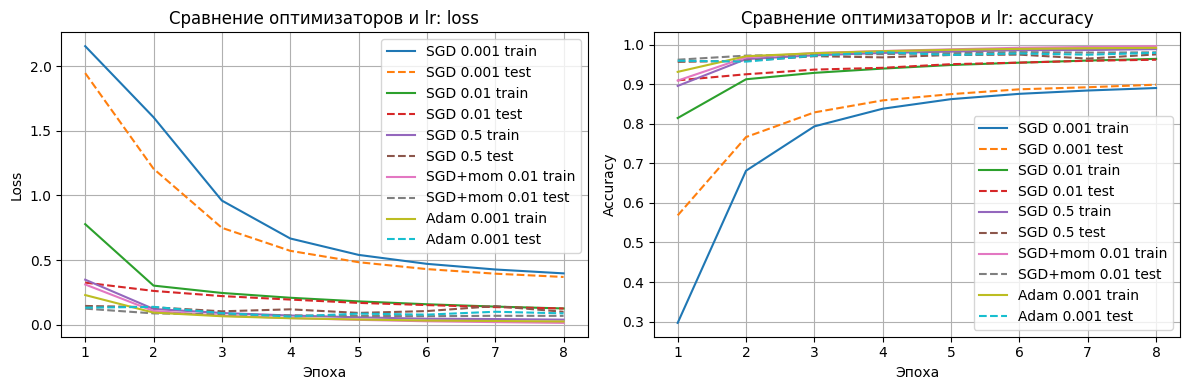

In [10]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [ ]:
analysis_text = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ АНАЛИЗ ВАШИХ КРИВЫХ.
1)  SGD с lr=0.001
Кривые loss и accuracy для этой конфигурации демонстрируют медленное обучение.
На начальных эпохах (1–3) точность (accuracy) растёт относительно неторопливо:
на 1-й эпохе train_acc = 0.2968, test_acc = 0.5684;
к 3-й эпохе train_acc достигает лишь 0.7934, test_acc — 0.8287.
Loss также снижается медленно: с 2.1537 (1-я эпоха) до 0.3970 (8-я эпоха). 
К концу обучения (8 эпох) точность выходит на разумный, но не максимальный уровень:
train_acc = 0.8902;
test_acc = 0.8987.
Форма кривых плавная, без резких скачков, но очевидно, что при таком малом learning rate 
модель требует значительно больше эпох для достижения высокой точности.

2) SGD с lr=0.5
Конфигурация с lr=0.5 демонстрирует очень быстрое снижение loss и рост accuracy, 
однако сопровождается определёнными рисками:
loss на 1-й эпохе уже составляет 0.3483 (train) и 0.1451 (test) — значительно ниже, чем у lr=0.001;
точность стремительно растёт: train_acc = 0.8956, test_acc = 0.9563 уже на 1-й эпохе.
К 8-й эпохе показатели достигают:
train_acc = 0.9885;
test_acc = 0.9752;
train_loss = 0.0394;
test_loss = 0.0998.
Однако на графиках видны рывковые участки и небольшие колебания accuracy 
(например, снижение test_acc с 0.9738 до 0.9646 между 5-й и 7-й эпохами),
что указывает на некоторую нестабильность обучения. 
Это классический признак слишком большого learning rate — модель "перепрыгивает" через минимумы функции потерь,
что может приводить к колебаниям.

3) SGD с lr=0.01
Эта конфигурация демонстрирует оптимальный баланс между скоростью и стабильностью:
уже на 1-й эпохе достигаются высокие значения: train_acc = 0.8144, test_acc = 0.9097, train_loss = 0.7776, test_loss = 0.3255;
кривые loss и accuracy плавные, без резких скачков;
к 8-й эпохе модель показывает:
train_acc = 0.9639;
test_acc = 0.9617;
train_loss = 0.1257;
test_loss = 0.1253.
Это подтверждает, что lr=0.01 — работоспособный компромисс: обучение идёт быстро, но при этом остаётся достаточно стабильным.

4) SGD с lr=0.01 и momentum=0.9
Добавление momentum существенно улучшило динамику обучения:

на 1-й эпохе: train_acc = 0.9090, test_acc = 0.9618, train_loss = 0.3111, test_loss = 0.1242 — лучше, чем у чистого SGD lr=0.01;
кривые loss и accuracy стали ещё более плавными, без "шума";
к 8-й эпохе достигнуты лучшие результаты среди всех SGD-конфигураций:
train_acc = 0.9960;
test_acc = 0.9804;
train_loss = 0.0141;
test_loss = 0.0685.
Momentum позволил:

ускорить сходимость (по сравнению с чистым SGD lr=0.01);
снизить колебания loss;
улучшить финальную точность (test_acc на 2% выше, чем у SGD lr=0.01).

5) Adam с lr=0.001
Adam продемонстрировал наиболее быстрое достижение высокой точности:

уже на 1-й эпохе: train_acc = 0.9311, test_acc = 0.9592, train_loss = 0.2294, test_loss = 0.1319 — лучше, чем у всех конфигураций SGD на старте;
кривые loss и accuracy плавные, без резких колебаний;
к 8-й эпохе:
train_acc = 0.9919;
test_acc = 0.9791;
train_loss = 0.0250;
test_loss = 0.0878.
Особенности Adam:

быстрый старт — за счёт адаптивного learning rate для каждого параметра;
стабильность — loss и accuracy снижаются/растут плавно;
отсутствие переобучения — разница между train_loss и test_loss невелика, train_acc лишь немного выше test_acc.

Итоговые выводы
Малый lr (0.001) замедляет обучение, требует больше эпох для достижения высокой точности.
Большой lr (0.5) ускоряет обучение, но вносит нестабильность (колебания accuracy, рывки в loss).
Средний lr (0.01) — хороший компромисс между скоростью и стабильностью.
Momentum существенно улучшает SGD: ускоряет сходимость, снижает колебания, повышает финальную точность.
Adam — лидер по скорости достижения высокой точности, отличается стабильностью и низкой вероятностью переобучения.
Лучшая конфигурация: SGD с lr=0.01 и momentum=0.9 — сочетает скорость, стабильность и высокую финальную точность (test_acc = 0.9804).
Наиболее универсальная: Adam с lr=0.001 — быстро выходит на высокую точность с минимальной нестабильностью (test_acc = 0.9791).
""" 
print(analysis_text)

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [ ]:
final_conclusion = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ.
Итоговые практические выводы
1) Для SGD в задаче MNIST:

слишком маленькие lr — около 0.001: обучение идёт очень медленно, за 8 эпох точность не добирается до "потолка" (test_acc ~0.9);
рабочие lr — около 0.01: хороший баланс скорости и стабильности, модель быстро стартует и стабильно учится;
слишком агрессивные lr — около 0.5: обучение ускоряется, но появляются "дёргания" — accuracy колеблется, loss снижается рывками.

2)SGD с momentum я бы использовал, когда:

нужно ускорить обучение по сравнению с обычным SGD;
хочется снизить "шум" в процессе обучения (колебания loss и accuracy);
цель — добиться чуть более высокой финальной точности (например, поднять test_acc с 0.96 до 0.98).

Обычный SGD подойдёт, если:

задача простая и стабильная, нет сильных колебаний;
важна прозрачность процесса (momentum немного "запутывает" динамику обучения);
нет времени на тонкую настройку momentum — можно обойтись "чистым" SGD с разумным lr (0.01).

3)Adam я бы выбрал, когда:

нужно максимально быстро выйти на высокую точность (например, на этапе прототипирования);
хочется избежать тонкой настройки lr — Adam реже "ломается" при разных значениях;
важна стабильность обучения (кривые loss и accuracy почти всегда плавные).

4)Остался бы на SGD/SGD+Momentum, если:

важно понимать "физику" обучения (Adam сложнее интерпретировать — из‑за адаптивных learning rate для каждого веса);
задача чувствительна к lr, и я могу потратить время на подбор оптимального значения (например, lr=0.01 даёт отличные результаты);
ресурсы ограничены — SGD чуть эффективнее по памяти и вычислениям (на больших моделях это может быть критично).
В общем и целом: Adam — для скорости и удобства, SGD (особенно с momentum) — для контроля и понимания процесса.
"""
print(final_conclusion)